# Data Understanding and Focused EDA

This notebook checks whether the public NBA shot data is reliable enough for probability modeling and explores only the patterns that may affect feature engineering or validation.

The 2024-25 season is reserved for final testing. Only its row count and columns are checked here.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
SEASON_LABELS = {2021: "2021-22", 2022: "2022-23", 2023: "2023-24", 2024: "2024-25"}
DATA_PATHS = {year: DATA_DIR / f"{year}.parquet" for year in SEASON_LABELS}

missing_files = [str(path) for path in DATA_PATHS.values() if not path.exists()]
assert not missing_files, f"Missing raw data files: {missing_files}"

## 1. Structural check across all four seasons

Parquet metadata lets us confirm that the future holdout has the expected structure without analyzing its outcomes.

In [2]:
schema_records = []
reference_schema = None

for year, path in DATA_PATHS.items():
    parquet_file = pq.ParquetFile(path)
    current_schema = [(field.name, str(field.type)) for field in parquet_file.schema_arrow]
    if reference_schema is None:
        reference_schema = current_schema

    schema_records.append(
        {
            "season": SEASON_LABELS[year],
            "rows": parquet_file.metadata.num_rows,
            "columns": parquet_file.metadata.num_columns,
            "schema_matches_2021_22": current_schema == reference_schema,
        }
    )

schema_audit = pd.DataFrame(schema_records)
assert schema_audit["schema_matches_2021_22"].all()
schema_audit

,season,rows,columns,schema_matches_2021_22
0,2021-22,216722,26,True
1,2022-23,217218,26,True
2,2023-24,218701,26,True
3,2024-25,219527,26,True


## 2. Load development seasons only

The 2021-22 through 2023-24 seasons are available for understanding and model development. The 2024-25 holdout is intentionally not loaded into the analysis DataFrame.

In [3]:
development_frames = []
for year in (2021, 2022, 2023):
    season_frame = pd.read_parquet(DATA_PATHS[year])
    season_frame["season_label"] = SEASON_LABELS[year]
    development_frames.append(season_frame)

shots = pd.concat(development_frames, ignore_index=True)
shots["game_date"] = pd.to_datetime(shots["GAME_DATE"].astype(str), format="%Y%m%d")

assert len(shots) == 652_641
assert set(shots["_season"].unique()) == {2021, 2022, 2023}

season_summary = (
    shots.groupby("season_label", sort=False)
    .agg(
        shots=("SHOT_MADE_FLAG", "size"),
        make_rate=("SHOT_MADE_FLAG", "mean"),
        games=("GAME_ID", "nunique"),
        players=("PLAYER_ID", "nunique"),
        first_game=("game_date", "min"),
        last_game=("game_date", "max"),
    )
)
season_summary

,shots,make_rate,games,players,first_game,last_game
season_label,,,,,,
2021-22,216722,0.461,1230,596,2021-10-19,2022-04-10
2022-23,217218,0.475,1230,537,2022-10-18,2023-04-09
2023-24,218701,0.474,1230,568,2023-10-24,2024-04-14


## 3. Row grain, target, duplicates, and leakage

A row should represent one shot event. `GAME_ID` and `GAME_EVENT_ID` should therefore form a unique key. The target must be binary, and fields that reveal the result must not become predictors.

In [4]:
key_columns = ["GAME_ID", "GAME_EVENT_ID"]
target_values = sorted(shots["SHOT_MADE_FLAG"].dropna().unique().tolist())
duplicate_keys = int(shots.duplicated(key_columns).sum())
exact_duplicate_rows = int(shots.drop(columns=["season_label", "game_date"]).duplicated().sum())
constant_columns = shots.columns[shots.nunique(dropna=False) == 1].tolist()

integrity_summary = pd.Series(
    {
        "rows": len(shots),
        "unique_game_event_keys": shots[key_columns].drop_duplicates().shape[0],
        "duplicate_game_event_keys": duplicate_keys,
        "exact_duplicate_rows": exact_duplicate_rows,
        "target_values": target_values,
        "constant_columns": constant_columns,
    }
)

assert target_values == [0, 1]
assert duplicate_keys == 0
integrity_summary

rows                                                                 652641
unique_game_event_keys                                               652641
duplicate_game_event_keys                                                 0
exact_duplicate_rows                                                      0
target_values                                                        [0, 1]
constant_columns             [GRID_TYPE, SHOT_ATTEMPTED_FLAG, _season_type]
dtype: object

In [5]:
event_target_check = pd.crosstab(shots["EVENT_TYPE"], shots["SHOT_MADE_FLAG"])
event_target_check

SHOT_MADE_FLAG,0,1
EVENT_TYPE,,
Made Shot,0,306929
Missed Shot,345712,0


## 4. Missing values, cardinality, and valid ranges

In [6]:
missing_summary = (
    shots.isna().sum()
    .rename("missing_rows")
    .to_frame()
    .assign(missing_pct=lambda frame: frame["missing_rows"] / len(shots))
    .query("missing_rows > 0")
    .sort_values("missing_rows", ascending=False)
)

categorical_columns = [
    "ACTION_TYPE", "SHOT_TYPE", "SHOT_ZONE_BASIC", "SHOT_ZONE_AREA",
    "SHOT_ZONE_RANGE", "PLAYER_ID", "TEAM_ID"
]
cardinality_summary = shots[categorical_columns].nunique().sort_values(ascending=False).rename("unique_values").to_frame()

print(f"Columns with missing values: {len(missing_summary)}")
display(missing_summary)
cardinality_summary

Columns with missing values: 0


,missing_rows,missing_pct


,unique_values
PLAYER_ID,808
ACTION_TYPE,48
TEAM_ID,30
SHOT_ZONE_BASIC,7
SHOT_ZONE_AREA,6
SHOT_ZONE_RANGE,5
SHOT_TYPE,2


In [7]:
range_columns = ["PERIOD", "MINUTES_REMAINING", "SECONDS_REMAINING", "SHOT_DISTANCE", "LOC_X", "LOC_Y"]
range_summary = shots[range_columns].agg(["min", "max", "median"]).T

range_checks = pd.Series(
    {
        "invalid_period_rows": int((shots["PERIOD"] < 1).sum()),
        "invalid_minute_rows": int((~shots["MINUTES_REMAINING"].between(0, 12)).sum()),
        "minute_12_with_nonzero_seconds": int(((shots["MINUTES_REMAINING"] == 12) & (shots["SECONDS_REMAINING"] != 0)).sum()),
        "invalid_second_rows": int((~shots["SECONDS_REMAINING"].between(0, 59)).sum()),
        "negative_distance_rows": int((shots["SHOT_DISTANCE"] < 0).sum()),
        "regulation_or_overtime_periods": sorted(shots["PERIOD"].unique().tolist()),
    }
)

coordinate_distance = np.hypot(shots["LOC_X"], shots["LOC_Y"]) / 10
distance_difference = (coordinate_distance - shots["SHOT_DISTANCE"]).abs()
distance_alignment = pd.Series(
    {
        "coordinate_reported_correlation": coordinate_distance.corr(shots["SHOT_DISTANCE"]),
        "median_absolute_difference_feet": distance_difference.median(),
        "maximum_absolute_difference_feet": distance_difference.max(),
    }
)

display(range_summary)
display(range_checks)
distance_alignment

,min,max,median
PERIOD,1.000,7.000,2.000
MINUTES_REMAINING,0.000,12.000,5.000
SECONDS_REMAINING,0.000,59.000,29.000
SHOT_DISTANCE,0.000,88.000,13.000
LOC_X,-250.000,250.000,0.000
LOC_Y,-52.000,878.000,55.000


invalid_period_rows                                   0
invalid_minute_rows                                   0
minute_12_with_nonzero_seconds                        0
invalid_second_rows                                   0
negative_distance_rows                                0
regulation_or_overtime_periods    [1, 2, 3, 4, 5, 6, 7]
dtype: object

coordinate_reported_correlation    1.000
median_absolute_difference_feet    0.481
maximum_absolute_difference_feet   1.000
dtype: float64

## 5. Shot distance and shot value

Distance should be one of the strongest predictors, while two- versus three-point classification captures an important rule boundary.

,shots,make_rate
distance_band,,
0-4,215657,0.638
5-9,75789,0.427
10-14,53177,0.442
15-19,40600,0.422
20-24,100831,0.380
25-29,160361,0.354
30-39,4704,0.272
40-49,709,0.056
50+,813,0.015


,shots,make_rate
SHOT_TYPE,,
2PT Field Goal,395587,0.542
3PT Field Goal,257054,0.360


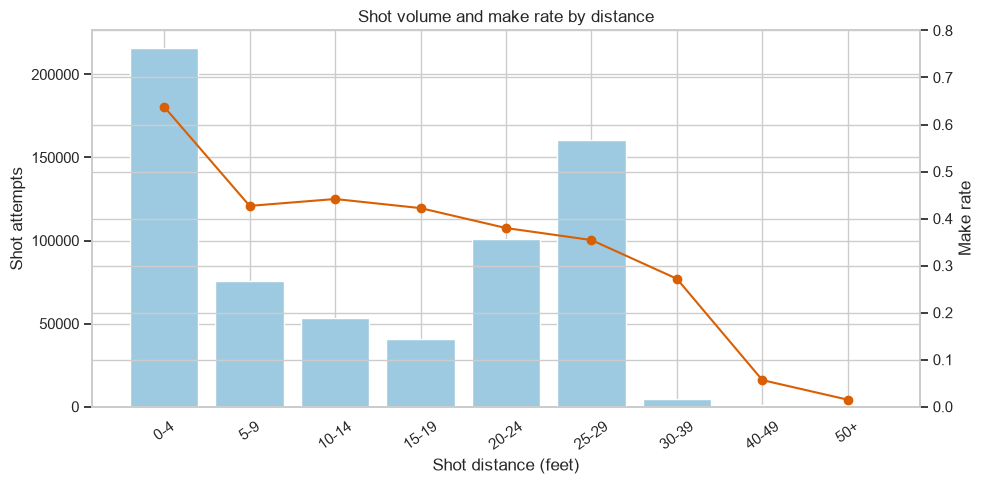

In [8]:
distance_edges = [-1, 4, 9, 14, 19, 24, 29, 39, 49, np.inf]
distance_labels = ["0-4", "5-9", "10-14", "15-19", "20-24", "25-29", "30-39", "40-49", "50+"]
shots["distance_band"] = pd.cut(shots["SHOT_DISTANCE"], bins=distance_edges, labels=distance_labels)

distance_summary = (
    shots.groupby("distance_band", observed=True)
    .agg(shots=("SHOT_MADE_FLAG", "size"), make_rate=("SHOT_MADE_FLAG", "mean"))
)
shot_type_summary = (
    shots.groupby("SHOT_TYPE")
    .agg(shots=("SHOT_MADE_FLAG", "size"), make_rate=("SHOT_MADE_FLAG", "mean"))
    .sort_values("shots", ascending=False)
)

display(distance_summary)
display(shot_type_summary)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(distance_summary.index.astype(str), distance_summary["shots"], color="#9ecae1")
ax1.set_ylabel("Shot attempts")
ax1.set_xlabel("Shot distance (feet)")
ax1.tick_params(axis="x", rotation=35)

ax2 = ax1.twinx()
ax2.plot(distance_summary.index.astype(str), distance_summary["make_rate"], color="#d95f02", marker="o")
ax2.set_ylabel("Make rate")
ax2.set_ylim(0, 0.8)
plt.title("Shot volume and make rate by distance")
plt.tight_layout()
plt.show()

## 6. Court zone and action context

These categorical fields describe different shot environments. Their volume and outcome variation help justify categorical modeling, but overlapping fields should be handled carefully in the logistic baseline.

,shots,make_rate
SHOT_ZONE_BASIC,,
Restricted Area,192638,0.661
Above the Break 3,190841,0.353
In The Paint (Non-RA),125198,0.438
Mid-Range,78064,0.415
Left Corner 3,33964,0.385
Right Corner 3,30657,0.387
Backcourt,1279,0.023


,shots,make_rate
ACTION_TYPE,,
Jump Shot,198223,0.366
Pullup Jump shot,79408,0.396
Driving Layup Shot,57680,0.483
Driving Floating Jump Shot,31837,0.431
Step Back Jump shot,31796,0.383
Layup Shot,19200,0.499
Running Layup Shot,19133,0.606
Driving Finger Roll Layup Shot,16707,0.633
Cutting Layup Shot,15989,0.694


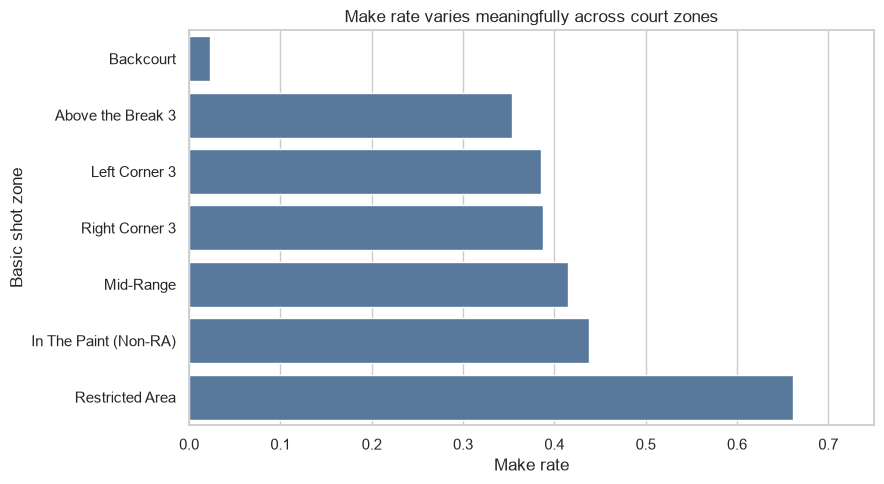

In [9]:
zone_summary = (
    shots.groupby("SHOT_ZONE_BASIC")
    .agg(shots=("SHOT_MADE_FLAG", "size"), make_rate=("SHOT_MADE_FLAG", "mean"))
    .sort_values("shots", ascending=False)
)
action_summary = (
    shots.groupby("ACTION_TYPE")
    .agg(shots=("SHOT_MADE_FLAG", "size"), make_rate=("SHOT_MADE_FLAG", "mean"))
    .sort_values("shots", ascending=False)
)

display(zone_summary)
display(action_summary.head(12))

plot_data = zone_summary.sort_values("make_rate")
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_data.reset_index(), x="make_rate", y="SHOT_ZONE_BASIC", color="#4c78a8")
plt.xlabel("Make rate")
plt.ylabel("Basic shot zone")
plt.title("Make rate varies meaningfully across court zones")
plt.xlim(0, 0.75)
plt.tight_layout()
plt.show()

## 7. Spatial make-rate pattern

The heatmap uses 2.5-foot court bins and hides bins with fewer than 100 attempts. It is descriptive, not a model evaluation.

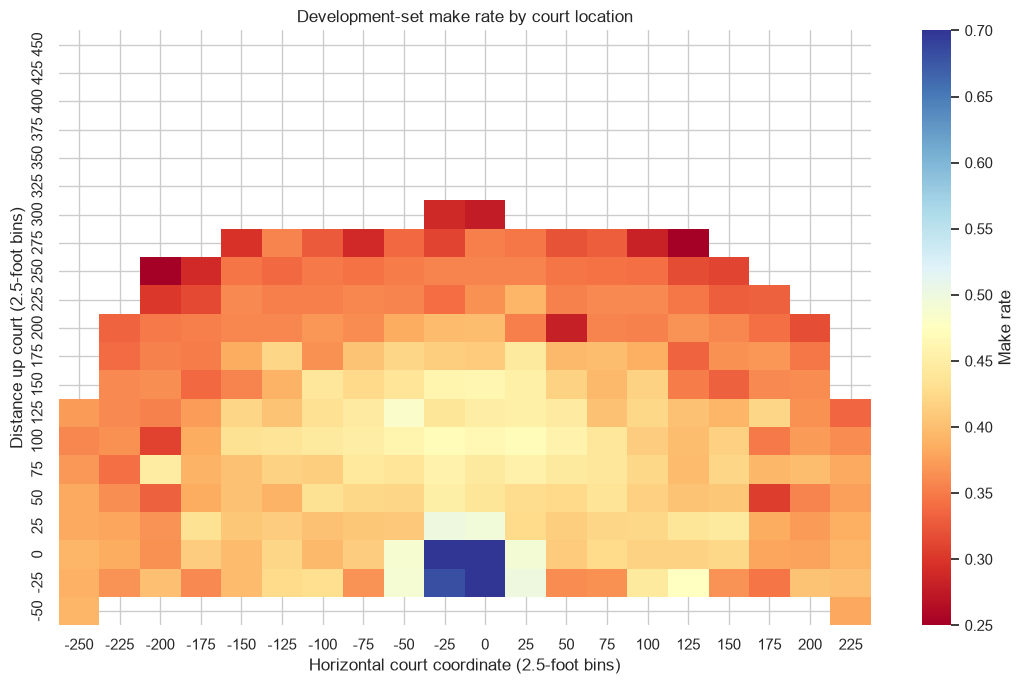

In [10]:
half_court = shots.loc[shots["LOC_X"].between(-250, 250) & shots["LOC_Y"].between(-50, 470)].copy()
x_edges = np.arange(-250, 276, 25)
y_edges = np.arange(-50, 496, 25)
half_court["x_bin"] = pd.cut(half_court["LOC_X"], bins=x_edges, labels=x_edges[:-1], include_lowest=True)
half_court["y_bin"] = pd.cut(half_court["LOC_Y"], bins=y_edges, labels=y_edges[:-1], include_lowest=True)

spatial_groups = half_court.groupby(["y_bin", "x_bin"], observed=True)["SHOT_MADE_FLAG"]
spatial_rate = spatial_groups.mean().unstack()
spatial_count = spatial_groups.size().unstack()
spatial_rate = spatial_rate.where(spatial_count >= 100)

plt.figure(figsize=(11, 7))
sns.heatmap(spatial_rate.iloc[::-1], cmap="RdYlBu", vmin=0.25, vmax=0.70, cbar_kws={"label": "Make rate"})
plt.xlabel("Horizontal court coordinate (2.5-foot bins)")
plt.ylabel("Distance up court (2.5-foot bins)")
plt.title("Development-set make rate by court location")
plt.tight_layout()
plt.show()

## 8. Period-clock context

The data includes game-clock time remaining in the period, not the possession shot clock. The analysis therefore avoids interpreting this as time remaining in a possession.

In [11]:
shots["seconds_remaining_in_period"] = shots["MINUTES_REMAINING"] * 60 + shots["SECONDS_REMAINING"]
clock_edges = [-1, 5, 24, 119, 359, 720]
clock_labels = ["0-5 sec", "6-24 sec", "25-119 sec", "2-5:59", "6-12:00"]
shots["period_clock_band"] = pd.cut(
    shots["seconds_remaining_in_period"], bins=clock_edges, labels=clock_labels
)
clock_summary = (
    shots.groupby("period_clock_band", observed=True)
    .agg(shots=("SHOT_MADE_FLAG", "size"), make_rate=("SHOT_MADE_FLAG", "mean"))
)
clock_summary

,shots,make_rate
period_clock_band,,
0-5 sec,15074,0.309
6-24 sec,12581,0.448
25-119 sec,90041,0.467
2-5:59,214406,0.475
6-12:00,320539,0.476


## 9. Temporal stability and unseen categories

The 2023-24 season acts as the latest development validation period. This check measures how much of that season comes from players, teams, or action labels absent from the two earlier seasons.

In [12]:
earlier = shots.loc[shots["_season"].isin([2021, 2022])]
latest_development = shots.loc[shots["_season"] == 2023]

stability_records = []
for column in ["PLAYER_ID", "TEAM_ID", "ACTION_TYPE", "SHOT_ZONE_BASIC"]:
    known_values = set(earlier[column].unique())
    unseen_mask = ~latest_development[column].isin(known_values)
    stability_records.append(
        {
            "feature": column,
            "training_categories": earlier[column].nunique(),
            "validation_categories": latest_development[column].nunique(),
            "unseen_validation_categories": latest_development.loc[unseen_mask, column].nunique(),
            "validation_shot_share_unseen": unseen_mask.mean(),
        }
    )

category_stability = pd.DataFrame(stability_records).set_index("feature")
category_stability

,training_categories,validation_categories,unseen_validation_categories,validation_shot_share_unseen
feature,,,,
PLAYER_ID,700,568,108,0.082
TEAM_ID,30,30,0,0.000
ACTION_TYPE,48,48,0,0.000
SHOT_ZONE_BASIC,7,7,0,0.000


## 10. Key findings

- **Reliable grain and target:** all 652,641 development rows have unique `(GAME_ID, GAME_EVENT_ID)` keys, the target is binary, and there are no exact duplicate rows. No row removal is needed before feature engineering.
- **No missing values:** the development data has no nulls. Missing-value imputation is unnecessary for the current source, although schema assertions should remain in the pipeline.
- **Direct leakage exists:** `EVENT_TYPE` maps perfectly to made versus missed shots. It must be excluded along with `SHOT_MADE_FLAG`; identifiers and the constant fields `GRID_TYPE`, `SHOT_ATTEMPTED_FLAG`, and `_season_type` are audit-only.
- **Temporal validation matters:** make rate shifts from 46.1% in 2021-22 to about 47.5% in the next two seasons. Model comparisons will therefore use season-held-out validation rather than a random split.
- **Nonlinear shot context matters:** make rate is 63.8% from 0-4 feet, 35.4% from 25-29 feet, and 1.5% from 50+ feet. The small increase from 5-9 to 10-14 feet also shows that distance alone does not describe shot difficulty; shot type, action, and zone should remain available.
- **Spatial features overlap but are not identical in use:** coordinate-derived and reported distance correlate at 0.9996, with less than a one-foot maximum difference caused by integer reporting. Keep `SHOT_DISTANCE` for interpretability and use coordinates to represent angle/location; avoid adding a redundant coordinate-distance feature.
- **Game-clock context is useful:** shots in the final five seconds of a period have a 30.9% make rate versus roughly 44.8%-47.6% in the broader clock bands. Add seconds remaining and a late-period indicator, while clearly distinguishing game clock from possession shot clock.
- **Player identity needs a controlled test:** 108 players in 2023-24 were unseen in the two earlier seasons and account for 8.2% of validation shots. The main model will use shot context; player/team identity will be tested separately with CatBoost.